# 02 - Neural Network Comparison

Notebook 01 compares classical ML baselines and can tune their hyperparameters.

This notebook adds a neural network and evaluates it with the same Leave-One-AoA-Out strategy so the comparison is fair.


## 1. Imports

In [1]:
from pathlib import Path
import os
import sys

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
os.environ.setdefault("TF_GPU_ALLOCATOR", "cuda_malloc_async")  # reduces fragmentation
os.environ.setdefault("TF_FORCE_GPU_ALLOW_GROWTH", "true")       # allocate VRAM on demand

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler

## 2. Connect The Notebook To The Project

In [2]:
PROJECT_ROOT = Path.cwd().resolve()

while not (PROJECT_ROOT / "cfd_ml").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

from cfd_ml.cp import CP_FEATURES, load_cp_modeling_data, split_cp_features
from cfd_ml.evaluation import regression_metrics, summarize_regression_scores
from cfd_ml.paths import METRICS_DIR

tf.keras.utils.set_random_seed(42)
tf.get_logger().setLevel("ERROR")

# ── GPU setup ────────────────────────────────────────────────────────────────
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    DEVICE = "/GPU:0"
    print(f"GPU available: {[g.name for g in gpus]}")
    print(f"Training will run on: {DEVICE}")
else:
    DEVICE = "/CPU:0"
    print("No GPU found — falling back to CPU.")
    print("Install CUDA + cuDNN and tensorflow-gpu to enable GPU acceleration.")

print(PROJECT_ROOT)

No GPU found — falling back to CPU.
Install CUDA + cuDNN and tensorflow-gpu to enable GPU acceleration.
D:\Sf355


In [ ]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print("Is built with CUDA:", tf.test.is_built_with_cuda())

Num GPUs Available:  0
Is built with CUDA: False


: 

## 3. Load Data

The neural network uses the same input features as Notebook 01:

- `x`, `y`
- `sin_AoA`, `cos_AoA`

The target is still `Pressure_Coefficient`.

In [3]:
cp_df = load_cp_modeling_data()
X, y, groups = split_cp_features(cp_df)

print("Rows:", len(cp_df))
print("Features:", CP_FEATURES)
print("AoA cases:", groups.nunique())
print("Mach", groups.nunique())

cp_df.head()

Rows: 24192
Features: ['x', 'y', 'sin_AoA', 'cos_AoA', 'Mach', 'AoA']
AoA cases: 126
Mach 126


,CaseID,x,y,sin_AoA,cos_AoA,Mach,AoA,Pressure_Coefficient
0,0.0_0.68,0.985397,0.000943,0.0,1.0,0.68,0.0,0.254906
1,0.0_0.68,0.969573,0.001489,0.0,1.0,0.68,0.0,0.270739
2,0.0_0.68,0.952680,0.001679,0.0,1.0,0.68,0.0,0.283429
3,0.0_0.68,0.934996,0.001511,0.0,1.0,0.68,0.0,0.285781
4,0.0_0.68,0.916822,0.000923,0.0,1.0,0.68,0.0,0.282259


## 4. Load Tuned Classical Model Results

Notebook 01 tunes the classical ML models with the same Leave-One-AoA-Out validation strategy. This notebook loads the tuned summary and fold-level Random Forest results so the neural network is compared against the strongest classical model from Notebook 01.


In [4]:
tuned_summary_path = METRICS_DIR / "cp_tuned_model_comparison_summary.csv"
tuned_fold_path = METRICS_DIR / "cp_tuned_model_comparison_by_aoa.csv"
rf_reference_name = "Random forest tuned"

missing_paths = [
    path for path in [tuned_summary_path, tuned_fold_path]
    if not path.exists()
]

if missing_paths:
    raise FileNotFoundError(
        "Run notebooks/01_cp_surrogate_model.ipynb through the tuning section first. "
        f"Missing: {[path.name for path in missing_paths]}"
    )

classical_summary = pd.read_csv(tuned_summary_path, index_col="model")
classical_scores = pd.read_csv(tuned_fold_path)

if rf_reference_name not in classical_summary.index:
    raise ValueError(f"{rf_reference_name!r} was not found in {tuned_summary_path.name}")

random_forest_scores = classical_scores[
    classical_scores["model"].eq(rf_reference_name)
].copy()

print(f"Loaded tuned classical summary: {tuned_summary_path.name}")
print(f"Loaded tuned fold scores: {tuned_fold_path.name}")
classical_summary


Loaded tuned classical summary: cp_tuned_model_comparison_summary.csv
Loaded tuned fold scores: cp_tuned_model_comparison_by_aoa.csv


,MAE_mean,RMSE_mean,R2_mean,RMSE_std
model,,,,
Random forest tuned,0.022443,0.042332,0.993984,0.032401
Gradient boosting tuned,0.049301,0.077125,0.984228,0.036953
Polynomial ridge tuned,0.236503,0.333645,0.731214,0.044422


## 5. Build The Neural Network

The neural network is a multilayer perceptron. It can learn nonlinear relationships between airfoil surface location, angle of attack, and Cp.

We scale both inputs and target values inside each fold to avoid data leakage.

In [5]:
def build_cp_neural_network(input_dim):
    regularizer = tf.keras.regularizers.l2(1e-6)

    model = tf.keras.Sequential([
        tf.keras.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(128, activation="swish", kernel_regularizer=regularizer),
        tf.keras.layers.Dropout(0.1),
        tf.keras.layers.Dense(64, activation="swish", kernel_regularizer=regularizer),
        tf.keras.layers.Dropout(0.1),
        tf.keras.layers.Dense(32, activation="swish", kernel_regularizer=regularizer),
        tf.keras.layers.Dense(1),
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="mse",
        metrics=["mae"],
    )
    return model


def build_early_stopping():
    return tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=12,
        restore_best_weights=True,
    )

## 5b. Hyperparameter Tuning With Keras Tuner

Uses **Hyperband** (an efficient early-stopping search) to find the best:

- Number of hidden layers (1–3)
- Units per layer (32, 64, 128, 256)
- Dropout rate (0.0, 0.05, 0.1, 0.2)
- L2 regularization (1e-7, 1e-6, 1e-5, 1e-4)
- Learning rate (1e-4, 5e-4, 1e-3, 3e-3)

Tuning runs on a single **representative validation split** (one held-out AoA × Mach case) rather than the full 126-fold LOGO loop — this keeps runtime manageable.
The best hyperparameters are then used to rebuild `build_cp_neural_network` before the full evaluation in Section 6.

In [6]:
import keras_tuner as kt

# ── Tuning settings ───────────────────────────────────────────────────────────
TUNER_REPRESENTATIVE_GROUP = groups.unique()[len(groups.unique()) // 2]  # middle case
TUNER_MAX_EPOCHS   = 80    # max epochs per trial
TUNER_FACTOR       = 3     # Hyperband reduction factor
TUNER_ITERATIONS   = 2     # how many full Hyperband brackets to run
TUNER_DIR          = PROJECT_ROOT / "reports" / "kt_tuner_cp_nn"
TUNER_PROJECT_NAME = "cp_nn_hyperband"

# ── Build a single train/val split for tuning ─────────────────────────────────
logo = LeaveOneGroupOut()
train_idx_t, val_idx_t = next(
    (tr, va)
    for tr, va in logo.split(X, y, groups)
    if groups.iloc[va[0]] == TUNER_REPRESENTATIVE_GROUP
)

scaler_X_t = StandardScaler()
scaler_y_t = StandardScaler()

X_train_t = scaler_X_t.fit_transform(X.iloc[train_idx_t].to_numpy())
X_val_t   = scaler_X_t.transform(X.iloc[val_idx_t].to_numpy())
y_train_t = scaler_y_t.fit_transform(y.iloc[train_idx_t].to_numpy().reshape(-1, 1))
y_val_t   = scaler_y_t.transform(y.iloc[val_idx_t].to_numpy().reshape(-1, 1))

INPUT_DIM = X_train_t.shape[1]

# ── Model builder for keras_tuner ─────────────────────────────────────────────
def build_tunable_model(hp):
    n_layers = hp.Int("n_layers", min_value=1, max_value=3, step=1)
    lr       = hp.Choice("learning_rate", [1e-4, 5e-4, 1e-3, 3e-3])
    l2_val   = hp.Choice("l2", [1e-7, 1e-6, 1e-5, 1e-4])
    dropout  = hp.Choice("dropout", [0.0, 0.05, 0.1, 0.2])

    regularizer = tf.keras.regularizers.l2(l2_val)
    inputs = tf.keras.Input(shape=(INPUT_DIM,))
    x = inputs
    for i in range(n_layers):
        units = hp.Choice(f"units_{i}", [32, 64, 128, 256])
        x = tf.keras.layers.Dense(units, activation="swish",
                                   kernel_regularizer=regularizer)(x)
        if dropout > 0:
            x = tf.keras.layers.Dropout(dropout)(x)
    outputs = tf.keras.layers.Dense(1)(x)

    model = tf.keras.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="mse",
        metrics=["mae"],
    )
    return model


# ── Run Hyperband search ───────────────────────────────────────────────────────
tuner = kt.Hyperband(
    build_tunable_model,
    objective="val_loss",
    max_epochs=TUNER_MAX_EPOCHS,
    factor=TUNER_FACTOR,
    hyperband_iterations=TUNER_ITERATIONS,
    directory=str(TUNER_DIR),
    project_name=TUNER_PROJECT_NAME,
    overwrite=True,
    seed=42,
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=10, restore_best_weights=True
)

print(f"Tuning on held-out group: {TUNER_REPRESENTATIVE_GROUP!r}")
print(f"Train size: {len(X_train_t):,}   Val size: {len(X_val_t):,}")
with tf.device(DEVICE):
    tuner.search(
        X_train_t, y_train_t,
        validation_data=(X_val_t, y_val_t),
        epochs=TUNER_MAX_EPOCHS,
        callbacks=[early_stop],
        verbose=0,
    )

# ── Extract best hyperparameters ───────────────────────────────────────────────
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]

print("\n── Best hyperparameters ──────────────────────────────")
print(f"  n_layers      : {best_hp.get('n_layers')}")
print(f"  learning_rate : {best_hp.get('learning_rate')}")
print(f"  l2            : {best_hp.get('l2')}")
print(f"  dropout       : {best_hp.get('dropout')}")
for i in range(best_hp.get('n_layers')):
    print(f"  units_{i}       : {best_hp.get(f'units_{i}')}")

# ── Override build_cp_neural_network with the tuned architecture ───────────────
def build_cp_neural_network(input_dim):
    """Tuned version — replaces the fixed architecture from Section 5."""
    n_layers    = best_hp.get("n_layers")
    lr          = best_hp.get("learning_rate")
    l2_val      = best_hp.get("l2")
    dropout_val = best_hp.get("dropout")
    regularizer = tf.keras.regularizers.l2(l2_val)

    inputs = tf.keras.Input(shape=(input_dim,))
    x = inputs
    for i in range(n_layers):
        units = best_hp.get(f"units_{i}")
        x = tf.keras.layers.Dense(units, activation="swish",
                                   kernel_regularizer=regularizer)(x)
        if dropout_val > 0:
            x = tf.keras.layers.Dropout(dropout_val)(x)
    outputs = tf.keras.layers.Dense(1)(x)

    model = tf.keras.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="mse",
        metrics=["mae"],
    )
    return model

print("\nbuild_cp_neural_network() now uses tuned hyperparameters.")
print("Proceed to Section 6 to run the full LOGO evaluation with the tuned model.")


Tuning on held-out group: '10.0_0.74'
Train size: 24,000   Val size: 192


c:\Users\KongP\Anaconda\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
c:\Users\KongP\Anaconda\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



── Best hyperparameters ──────────────────────────────
  n_layers      : 3
  learning_rate : 0.0005
  l2            : 1e-07
  dropout       : 0.0
  units_0       : 256
  units_1       : 256
  units_2       : 32

build_cp_neural_network() now uses tuned hyperparameters.
Proceed to Section 6 to run the full LOGO evaluation with the tuned model.


## 6. Evaluate The Neural Network

This cell may take longer than the classical ML baselines because it trains one neural network per held-out AoA case.

In [7]:
def evaluate_neural_network(X, y, groups, original_df, epochs=120, batch_size=64):
    splitter = LeaveOneGroupOut()
    fold_scores = []
    fold_predictions = []
    training_rows = []

    # Use original_df to pull the actual numeric AoA and Mach values
    for fold, (train_idx, test_idx) in enumerate(splitter.split(X, y, groups), start=1):
        
        # FIX: Get the actual numeric values from the original dataframe using the test indices
        test_case_row = original_df.iloc[test_idx].iloc[0]
        test_aoa = float(test_case_row["AoA"])
        test_mach = float(test_case_row["Mach"])

        X_train = X.iloc[train_idx].to_numpy()
        X_test = X.iloc[test_idx].to_numpy()
        y_train = y.iloc[train_idx].to_numpy().reshape(-1, 1)
        y_test = y.iloc[test_idx].to_numpy()

        # Scaling logic (Stay inside the loop to prevent leakage)
        scaler_X = StandardScaler()
        scaler_y = StandardScaler()

        X_train_scaled = scaler_X.fit_transform(X_train)
        X_test_scaled = scaler_X.transform(X_test)
        y_train_scaled = scaler_y.fit_transform(y_train)

        with tf.device(DEVICE):
            model = build_cp_neural_network(input_dim=X_train_scaled.shape[1])
            history = model.fit(
                X_train_scaled,
                y_train_scaled,
                validation_split=0.1,
                epochs=epochs,
                batch_size=batch_size,
                callbacks=[build_early_stopping()],
                verbose=0,
            )
            y_pred_scaled = model.predict(X_test_scaled, verbose=0)
        y_pred = scaler_y.inverse_transform(y_pred_scaled).ravel()

        # Update metrics to include Mach
        metrics = regression_metrics(y_test, y_pred)
        metrics.update({
            "fold": fold, 
            "AoA": test_aoa, 
            "Mach": test_mach, 
            "model": "Neural network"
        })
        fold_scores.append(metrics)

        # Include Mach in the prediction frame for plotting later
        prediction_frame = original_df.iloc[test_idx][["AoA", "Mach", "x", "y"]].copy()
        prediction_frame["y_true"] = y_test
        prediction_frame["y_pred"] = y_pred
        fold_predictions.append(prediction_frame)

        training_rows.append({
            "fold": fold,
            "AoA": test_aoa,
            "Mach": test_mach,
            "epochs_used": len(history.history["loss"]),
            "final_loss": history.history["loss"][-1],
            "final_val_loss": history.history["val_loss"][-1],
        })

        print(
            f"Fold {fold:>3} | AoA {test_aoa:>4.1f} | M {test_mach:.3f} | "
            f"RMSE {metrics['RMSE']:.4f} | R2 {metrics['R2']:.4f}"
        )

    return (
        pd.DataFrame(fold_scores),
        pd.concat(fold_predictions, ignore_index=True),
        pd.DataFrame(training_rows),
    )

In [8]:
nn_scores, nn_predictions, nn_training = evaluate_neural_network(X, y, groups, original_df=cp_df)
nn_scores.head()

Fold   1 | AoA  0.0 | M 0.680 | RMSE 0.0306 | R2 0.9937
Fold   2 | AoA  0.0 | M 0.700 | RMSE 0.0325 | R2 0.9932
Fold   3 | AoA  0.0 | M 0.720 | RMSE 0.0249 | R2 0.9962
Fold   4 | AoA  0.0 | M 0.740 | RMSE 0.0300 | R2 0.9949
Fold   5 | AoA  0.0 | M 0.760 | RMSE 0.0251 | R2 0.9968
Fold   6 | AoA  0.0 | M 0.780 | RMSE 0.0715 | R2 0.9762
Fold   7 | AoA  1.0 | M 0.680 | RMSE 0.0454 | R2 0.9894
Fold   8 | AoA  1.0 | M 0.700 | RMSE 0.0267 | R2 0.9965
Fold   9 | AoA  1.0 | M 0.720 | RMSE 0.0257 | R2 0.9969
Fold  10 | AoA  1.0 | M 0.740 | RMSE 0.0396 | R2 0.9933
Fold  11 | AoA  1.0 | M 0.760 | RMSE 0.0265 | R2 0.9972
Fold  12 | AoA  1.0 | M 0.780 | RMSE 0.0746 | R2 0.9773
Fold  13 | AoA 10.0 | M 0.680 | RMSE 0.0665 | R2 0.9919
Fold  14 | AoA 10.0 | M 0.700 | RMSE 0.0780 | R2 0.9886
Fold  15 | AoA 10.0 | M 0.720 | RMSE 0.0486 | R2 0.9955
Fold  16 | AoA 10.0 | M 0.740 | RMSE 0.0281 | R2 0.9985
Fold  17 | AoA 10.0 | M 0.760 | RMSE 0.0348 | R2 0.9977
Fold  18 | AoA 10.0 | M 0.780 | RMSE 0.0483 | R2

,MAE,RMSE,R2,fold,AoA,Mach,model
0,0.023945,0.030574,0.993699,1,0.0,0.68,Neural network
1,0.024331,0.032469,0.993234,2,0.0,0.70,Neural network
2,0.019962,0.024935,0.996231,3,0.0,0.72,Neural network
3,0.024264,0.029993,0.994915,4,0.0,0.74,Neural network
4,0.015545,0.025079,0.996759,5,0.0,0.76,Neural network


## 7. Compare Neural Network Against Tuned Random Forest

The main comparison is against `Random forest tuned`, because Notebook 01 identified it as the strongest classical Cp surrogate.


In [9]:
nn_summary = summarize_regression_scores(nn_scores)
comparison_summary = pd.concat([classical_summary, nn_summary]).sort_values("RMSE_mean")

rf_nn_summary = comparison_summary.loc[[rf_reference_name, "Neural network"]].copy()
rf_rmse = rf_nn_summary.loc[rf_reference_name, "RMSE_mean"]
nn_rmse = rf_nn_summary.loc["Neural network", "RMSE_mean"]

rf_nn_takeaway = pd.DataFrame([{
    "reference_model": rf_reference_name,
    "neural_network_RMSE": nn_rmse,
    "random_forest_RMSE": rf_rmse,
    "RMSE_gap_NN_minus_RF": nn_rmse - rf_rmse,
    "NN_RMSE_percent_higher": ((nn_rmse / rf_rmse) - 1) * 100,
    "winner": "Neural network" if nn_rmse < rf_rmse else rf_reference_name,
}])

rf_vs_nn_by_aoa = (
    nn_scores[["fold", "AoA", "MAE", "RMSE", "R2"]]
    .rename(columns={
        "MAE": "NN_MAE",
        "RMSE": "NN_RMSE",
        "R2": "NN_R2",
    })
    .merge(
        random_forest_scores[["AoA", "MAE", "RMSE", "R2"]].rename(columns={
            "MAE": "RF_MAE",
            "RMSE": "RF_RMSE",
            "R2": "RF_R2",
        }),
        on="AoA",
        how="inner",
    )
    .sort_values("AoA")
)
rf_vs_nn_by_aoa["RMSE_gap_NN_minus_RF"] = (
    rf_vs_nn_by_aoa["NN_RMSE"] - rf_vs_nn_by_aoa["RF_RMSE"]
)
rf_vs_nn_by_aoa["winner"] = np.where(
    rf_vs_nn_by_aoa["NN_RMSE"] < rf_vs_nn_by_aoa["RF_RMSE"],
    "Neural network",
    rf_reference_name,
)

display(comparison_summary)
display(rf_nn_summary)
display(rf_vs_nn_by_aoa)
rf_nn_takeaway


,MAE_mean,RMSE_mean,R2_mean,RMSE_std
model,,,,
Random forest tuned,0.022443,0.042332,0.993984,0.032401
Neural network,0.026538,0.043403,0.995016,0.017286
Gradient boosting tuned,0.049301,0.077125,0.984228,0.036953
Polynomial ridge tuned,0.236503,0.333645,0.731214,0.044422


,MAE_mean,RMSE_mean,R2_mean,RMSE_std
model,,,,
Random forest tuned,0.022443,0.042332,0.993984,0.032401
Neural network,0.026538,0.043403,0.995016,0.017286


,fold,AoA,NN_MAE,NN_RMSE,NN_R2,RF_MAE,RF_RMSE,RF_R2,RMSE_gap_NN_minus_RF,winner
0,1,0.0,0.023945,0.030574,0.993699,0.013657,0.016970,0.998059,0.013604,Random forest tuned
1,1,0.0,0.023945,0.030574,0.993699,0.006397,0.010281,0.999322,0.020293,Random forest tuned
2,1,0.0,0.023945,0.030574,0.993699,0.012276,0.020919,0.997347,0.009656,Random forest tuned
3,1,0.0,0.023945,0.030574,0.993699,0.014582,0.026013,0.996175,0.004561,Random forest tuned
8,2,0.0,0.024331,0.032469,0.993234,0.012276,0.020919,0.997347,0.011550,Random forest tuned
...,...,...,...,...,...,...,...,...,...,...
475,80,20.0,0.029154,0.052887,0.993525,0.008971,0.010397,0.999750,0.042489,Random forest tuned
476,80,20.0,0.029154,0.052887,0.993525,0.008707,0.012881,0.999624,0.040006,Random forest tuned
477,80,20.0,0.029154,0.052887,0.993525,0.010864,0.011997,0.999683,0.040889,Random forest tuned
478,80,20.0,0.029154,0.052887,0.993525,0.009581,0.010157,0.999780,0.042729,Random forest tuned


,reference_model,neural_network_RMSE,random_forest_RMSE,RMSE_gap_NN_minus_RF,NN_RMSE_percent_higher,winner
0,Random forest tuned,0.043403,0.042332,0.001071,2.530946,Random forest tuned


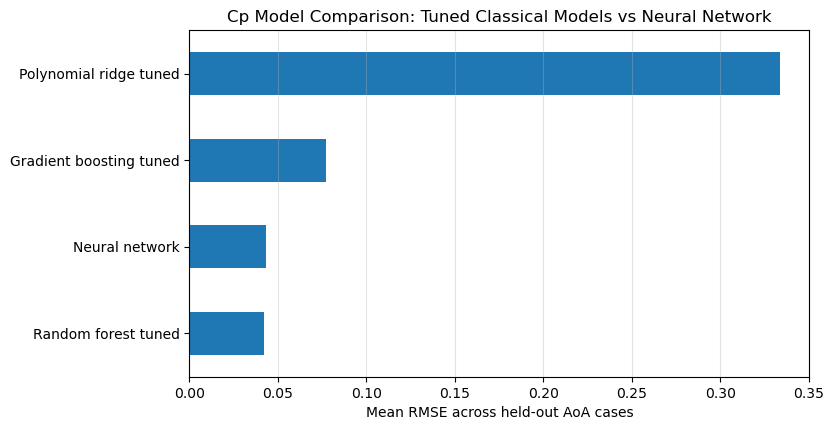

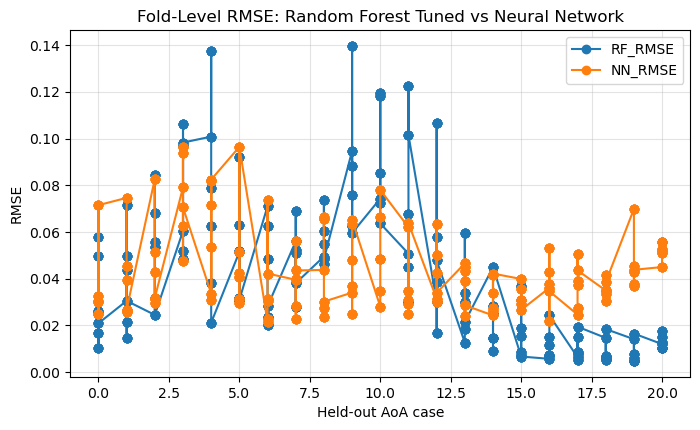

In [10]:
ax = comparison_summary["RMSE_mean"].sort_values(ascending=True).plot(
    kind="barh",
    figsize=(8, 4.5),
)
ax.set_xlabel("Mean RMSE across held-out AoA cases")
ax.set_ylabel("")
ax.set_title("Cp Model Comparison: Tuned Classical Models vs Neural Network")
ax.grid(True, axis="x", alpha=0.35)
plt.show()

ax = rf_vs_nn_by_aoa.plot(
    x="AoA",
    y=["RF_RMSE", "NN_RMSE"],
    marker="o",
    figsize=(8, 4.5),
)
ax.set_xlabel("Held-out AoA case")
ax.set_ylabel("RMSE")
ax.set_title("Fold-Level RMSE: Random Forest Tuned vs Neural Network")
ax.grid(True, alpha=0.35)
plt.show()

## 8. Inspect Neural Network Predictions

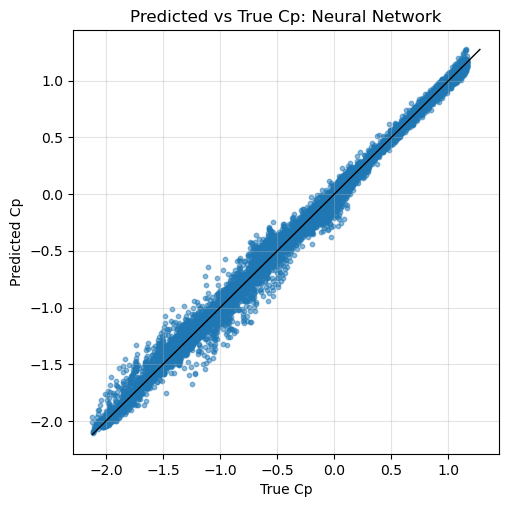

In [11]:
plt.figure(figsize=(5.5, 5.5))
plt.scatter(nn_predictions["y_true"], nn_predictions["y_pred"], s=10, alpha=0.5)

min_value = min(nn_predictions["y_true"].min(), nn_predictions["y_pred"].min())
max_value = max(nn_predictions["y_true"].max(), nn_predictions["y_pred"].max())
plt.plot([min_value, max_value], [min_value, max_value], color="black", linewidth=1)

plt.xlabel("True Cp")
plt.ylabel("Predicted Cp")
plt.title("Predicted vs True Cp: Neural Network")
plt.grid(True, alpha=0.35)
plt.show()

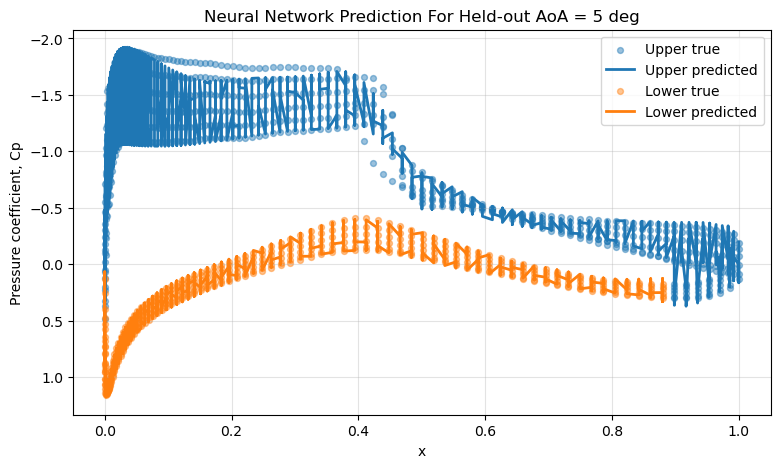

In [12]:
def plot_nn_prediction_for_aoa(predictions, aoa):
    case = predictions[predictions["AoA"] == aoa].copy()
    if case.empty:
        raise ValueError(f"AoA {aoa} not found in predictions")

    upper = case[case["y"] > 0].sort_values("x")
    lower = case[case["y"] <= 0].sort_values("x")

    plt.figure(figsize=(9, 5))
    plt.scatter(upper["x"], upper["y_true"], s=18, alpha=0.45, label="Upper true")
    plt.plot(upper["x"], upper["y_pred"], linewidth=2, label="Upper predicted")
    plt.scatter(lower["x"], lower["y_true"], s=18, alpha=0.45, label="Lower true")
    plt.plot(lower["x"], lower["y_pred"], linewidth=2, label="Lower predicted")

    plt.gca().invert_yaxis()
    plt.xlabel("x")
    plt.ylabel("Pressure coefficient, Cp")
    plt.title(f"Neural Network Prediction For Held-out AoA = {aoa:g} deg")
    plt.grid(True, alpha=0.35)
    plt.legend()
    plt.show()


plot_nn_prediction_for_aoa(nn_predictions, aoa=5.0)

## 9. Save Neural Network Metrics

In [13]:
METRICS_DIR.mkdir(parents=True, exist_ok=True)

comparison_summary_path = METRICS_DIR / "cp_nn_comparison_summary.csv"
rf_nn_takeaway_path = METRICS_DIR / "cp_nn_vs_random_forest_summary.csv"
rf_vs_nn_by_aoa_path = METRICS_DIR / "cp_nn_vs_random_forest_by_aoa.csv"
nn_scores_path = METRICS_DIR / "cp_nn_scores_by_aoa.csv"
nn_training_path = METRICS_DIR / "cp_nn_training_by_aoa.csv"

comparison_summary.to_csv(comparison_summary_path)
rf_nn_takeaway.to_csv(rf_nn_takeaway_path, index=False)
rf_vs_nn_by_aoa.to_csv(rf_vs_nn_by_aoa_path, index=False)
nn_scores.to_csv(nn_scores_path, index=False)
nn_training.to_csv(nn_training_path, index=False)

print(comparison_summary_path)
print(rf_nn_takeaway_path)
print(rf_vs_nn_by_aoa_path)
print(nn_scores_path)
print(nn_training_path)

D:\Sf355\reports\metrics\cp_nn_comparison_summary.csv
D:\Sf355\reports\metrics\cp_nn_vs_random_forest_summary.csv
D:\Sf355\reports\metrics\cp_nn_vs_random_forest_by_aoa.csv
D:\Sf355\reports\metrics\cp_nn_scores_by_aoa.csv
D:\Sf355\reports\metrics\cp_nn_training_by_aoa.csv


## Conclusion

The neural network is compared directly against the tuned Random Forest from Notebook 01 using the same Leave-One-AoA-Out folds.

If the neural network beats `Random forest tuned`, it is justified as the stronger Cp surrogate. If tuned Random Forest still wins, that is also a useful ML conclusion: for this small tabular CFD dataset, tree ensembles may generalize better than the fixed neural-network architecture.